# Problem Statement

Social media platforms like Twitter have become critical communication channels
during natural disasters and emergency situations. However, not every tweet
containing disaster-related language actually describes a real event. Many use
such language in a non-literal way (i.e. metaphoric, hypothetic).

The goal of this project is to build a text classification model that
distinguishes between tweets reporting real disasters and those that do not.
The dataset consists of 7,613 labeled tweets and was originally compiled
for binary text classification research.

Accurate classification has real-world relevance: automated disaster detection
systems could help emergency services and journalists identify critical
information faster during crises.

# Exploratory Data Analysis
## Data Overview

In [1]:
import pandas as pd

# Display full text content without truncation
pd.set_option("display.max_colwidth", None)

# Load the dataset
path = 'Data/'
df = pd.read_csv(path + 'train.csv')

# Display shape and first rows
print(df.shape)

# Display random sample for unbiased inspection
df.sample(20, random_state=42)

(7613, 2)


,text,target
2644,So you have a new weapon that can cause un-imaginable destruction.,1
2227,The f$&amp;@ing things I do for #GISHWHES Just got soaked in a deluge going for pads and tampons. Thx @mishacollins @/@,0
5448,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL police can catch a pickpocket in Liverpool Stree... http://t.co/vXIn1gOq4Q,1
132,Aftershock back to school kick off was great. I want to thank everyone for making it possible. What a great night.,0
6845,in response to trauma Children of Addicts develop a defensive self - one that decreases vulnerability. (3,0
5559,@Calum5SOS you look like you got caught in a rainstorm this is amazing and disgusting at the same time,0
1765,my favorite lady came to our volunteer meeting\nhopefully joining her youth collision and i am excite http://t.co/Ij0wQ490cS,1
1817,@brianroemmele UX fail of EMV - people want to insert and remove quickly like a gas pump stripe reader. 1 person told me it crashed the POS,1
6810,Can't find my ariana grande shirt this is a fucking tragedy,0
4398,The Murderous Story Of AmericaÛªs First Hijacking http://t.co/EYUGk6byxr,1


## Missing Values

In [2]:
# Check for missing values per column
df.isnull().sum()

text      0
target    0
dtype: int64

## Duplicates

In [3]:
# Check for duplicate tweets
n_duplicates = df.duplicated(subset="text").sum()
print(f"Number of duplicate tweets: {n_duplicates}")

# Display duplicates for inspection
df[df.duplicated(subset="text", keep=False)].sort_values("text").head(20)

Number of duplicate tweets: 110


,text,target
4290,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,0
4299,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,0
4312,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in Surah Humaza. #Reflect,1
6363,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6366,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6373,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6377,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6378,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
6392,#Bestnaijamade: 16yr old PKK suicide bomber who detonated bomb in ... http://t.co/KSAwlYuX02 bestnaijamade bestnaijamade bestnaijamade beÛ_,1
2822,#KCA #VoteJKT48ID 12News: UPDATE: A family of 3 has been displaced after fired damaged housed near 90th and Osborn. Fire extinguished no iÛ_,1


In [4]:
# Remove duplicate tweets, keeping first occurrence
df = df.drop_duplicates(subset="text", keep="first")
print(f"Dataset size after removing duplicates: {df.shape}")

Dataset size after removing duplicates: (7503, 2)


In [5]:
# Check for values in target column
df['target'].unique()

array([1, 0])

## Class Distribution

target
0    4305
1    3198
Name: count, dtype: int64


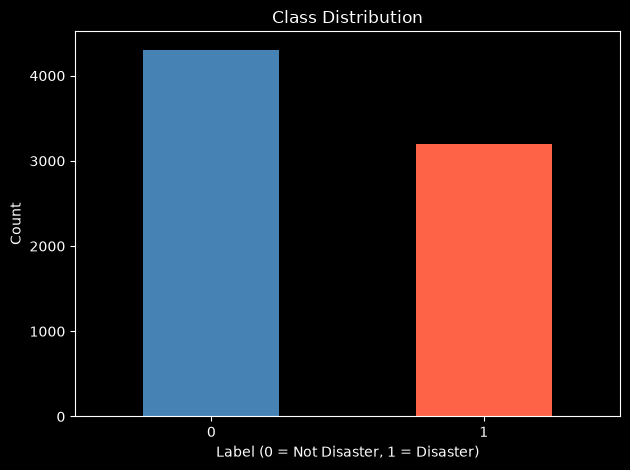

In [6]:
import matplotlib.pyplot as plt

# Inspect class distribution
class_counts = df["target"].value_counts()
print(class_counts)

# Visualize class distribution
class_counts.plot(
    kind="bar",
    color=["steelblue", "tomato"]
)
plt.title("Class Distribution")
plt.xlabel("Label (0 = Not Disaster, 1 = Disaster)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("class_distribution.jpeg", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
class_distribution = pd.DataFrame({
    "count": df["target"].value_counts(),
    "percent": df["target"].value_counts() / len(df) * 100
})

print(class_distribution.round(1))

        count  percent
target                
0        4305     57.4
1        3198     42.6


**Observations**

- The dataset contains 7,503 tweets (after duplicate removal) across two columns: text and target
- The target variable is binary, with 1 indicating a real disaster tweet and 0 indicating a non-disaster tweet.

- The class distribution is moderately imbalanced: 57% of tweets are labeled as non-disaster and 43% as disaster.
- This imbalance is relevant for the choice of evaluation metrics and will be addressed in the model evaluation section.

# Preprocessing
## Character inspection

In [8]:
import re

# Show tweets containing non-ASCII characters
mask = df["text"].apply(lambda x: bool(re.search(r"[^\x00-\x7F]", x)))
print(f"{mask.sum()} tweets contain non-ASCII characters")

pd.set_option("display.max_colwidth", None)
df[mask]["text"].head(10)

677 tweets contain non-ASCII characters


38       Barbados #Bridgetown JAMAICA ÛÒ Two cars set ablaze: SANTA CRUZ ÛÓ Head of the St Elizabeth Police Superintende...  http://t.co/wDUEaj8Q4J
52             SANTA CRUZ ÛÓ Head of the St Elizabeth Police Superintendent Lanford Salmon has r ... - http://t.co/vplR5Hka2u http://t.co/SxHW2TNNLf
53                                                    Police: Arsonist Deliberately Set Black Church In North CarolinaåÊAblaze http://t.co/pcXarbH9An
57                       Set our hearts ablaze and every city was a gift And every skyline was like a kiss upon the lips @Û_ https://t.co/cYoMPZ1A0Z
71        #stlouis #caraccidentlawyer Speeding Among Top Causes of Teen Accidents https://t.co/k4zoMOF319 https://t.co/S2kXVM0cBA Car Accident teeÛ_
87     RT nAAYf: First accident in years. Turning onto Chandanee Magu from near MMA. Taxi rammed into me while I was halfway turned. Everyone confÛ_
104        320 [IR] ICEMOON [AFTERSHOCK] | http://t.co/yNXnvVKCDA | @djicemoon | #Dubstep #TrapMusic

In [9]:
# Count tweets containing any Û-based encoding artifact
mask_artifacts = df["text"].str.contains("Û", regex=False)
print(f"{mask_artifacts.sum()} tweets contain Û-based encoding artifacts")

# Count tweets containing Scandinavian or other genuine special characters
mask_scandinavian = df["text"].str.contains("[åäöøæÅÄÖØÆ]", regex=True)
print(f"{mask_scandinavian.sum()} tweets contain Scandinavian special characters")

592 tweets contain Û-based encoding artifacts
80 tweets contain Scandinavian special characters


**Character Inspection**

- Before defining the preprocessing pipeline, the raw text was inspected for non-ASCII characters.
    - ASCII is a character encoding standard covering 128 characters: the Latin alphabet, digits, basic punctuation and control characters. Everything beyond this range, such as emojis, Arabic or Chinese script, and typographic special characters, is considered non-ASCII.
- Of the 7,503 tweets in the dataset, 677 contained non-ASCII characters.
    - Examples:
        - Manual inspection revealed 592 tweets (7.9% of the dataset) containing encoding artifacts from the Twitter API, appearing as character sequences such as ÛÒ or ÛÓ, with no recoverable semantic content.
        - A smaller share of 80 tweets (1.1%) contained genuine special characters from non-English texts, such as Scandinavian characters (e.g. å), suggesting the dataset includes tweets from non-English speaking users.
- All non-ASCII characters are therefore removed as the first preprocessing step.

## Preprocessing Pipeline

In [10]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove non-ASCII characters (encoding artifacts and emojis)
    text = re.sub(r"[^\x00-\x7F]", "", text)
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    # Remove mention symbols and hashtag symbols but keep the text
    text = re.sub(r"[@#]", "", text)
    # Remove punctuation and numbers
    text = re.sub(r"[^a-z\s]", "", text)
    # Remove extra whitespace
    text = " ".join(text.split())
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [t for t in tokens if t not in stop_words]
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df["text_clean"] = df["text"].apply(preprocess_text)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/matthiasmuschket/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [11]:
df.head()

,text,target,text_clean
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1,deed reason earthquake may allah forgive u
1,Forest fire near La Ronge Sask. Canada,1,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,1,resident asked shelter place notified officer evacuation shelter place order expected
3,"13,000 people receive #wildfires evacuation orders in California",1,people receive wildfire evacuation order california
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1,got sent photo ruby alaska smoke wildfire pours school


**The preprocessing pipeline applies the following steps in order:**

- Lowercase conversion: ensures identical words are not treated as distinct tokens
- Non-ASCII removal: eliminates encoding artifacts introduced by the Twitter API
- URL removal: URLs carry no semantic information relevant to classification
- Mention and hashtag symbol removal: the symbols @ and # are stripped while preserving the underlying text, since hashtag content such as "wildfire" or "earthquake" may carry relevant signal for the classifier
- Punctuation and digit removal: TF-IDF operates on word tokens and these characters do not contribute meaningful features in this context
- Whitespace normalization: after removal of URLs, symbols and punctuation, multiple consecutive whitespace characters are collapsed into a single space
- Tokenization: splits text into individual word tokens
- Stopword removal: reduces noise from high-frequency function words
- Lemmatization: reduces words to their base dictionary form, preferred over stemming because it produces readable, valid word forms that support interpretability of TF-IDF feature weights

# Tweet Classification via Machine Learning
## Train-Test Split

The data is split into training, validation and test sets. The training set
is used to fit the model and to assess generalization behavior via
cross-validation, the validation set for hyperparameter tuning and threshold
selection, and the test set exclusively for the final evaluation, untouched
during development to provide an unbiased performance estimate.

In [12]:
# Define Features
X = df["text_clean"]

# Define Labels
y = df["target"]

In [13]:
from sklearn.model_selection import train_test_split

# Step 1: Split off test set first - this will only be used once for final evaluation
X_remainder, X_test, y_remainder, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Step 2: Split remainder into training and validation sets
# Validation set is used for threshold optimization and comparing tuned vs. untuned models - the test set stays untouched here
X_train, X_val, y_train, y_val = train_test_split(
    X_remainder,
    y_remainder,
    test_size=0.2,
    stratify=y_remainder,
    random_state=42
)

print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

Train: 4801, Validation: 1201, Test: 1501


## Vectorization: TF-IDF

For vectorization, TF-IDF (Term Frequency-Inverse Document Frequency) is used.
TF-IDF weights each term by how frequently it appears in a given document
relative to how commonly it appears across the entire corpus. Terms that are
frequent in a specific tweet but rare across all tweets receive a high weight,
making them strong discriminative features.

The following TF-IDF parameters are optimized during hyperparameter tuning
in Section 5:

- max_features: limits the vocabulary to the most frequent terms, reducing
  dimensionality while retaining the most informative tokens. Values tested:
  3000, 5000, 10000.
- ngram_range: defines whether only single words (unigrams) or also
  multi-word sequences (bigrams, trigrams) are included as features. Values
  tested: (1,1), (1,2), (1,3), (1,4).

## Why TF-IDF

- For short, keyword-driven texts such as tweets, TF-IDF is particularly effective: domain-specific terms like "wildfire" or "earthquake" appear rarely across the corpus but frequently in disaster tweets, receiving high weights as a result
- Bag-of-Words was dismissed as it treats all words as equally important and ignores document-level weighting
- Transformer-based models could handle ambiguous language better, but without fine-tuning the expected gain is modest and the added complexity not justified given the scope of this project
-
- TF-IDF requires word-level features and is therefore paired with a word tokenizer (NLTKs word_tokenize). Subword tokenizers such as BPE or WordPiece are tightly coupled to Transformer architectures and incompatible with TF-IDF.
- One fundamental limitation of TF-IDF is its inability to capture contextual meaning. "Bank" carries an entirely different meaning in "river bank" versus "financial institution", yet TF-IDF assigns the same feature weight in both cases. This limitation is revisited in the error analysis section.

## Why Logistic Regression

- Well-established baseline for text classification that pairs naturally
  with high-dimensional sparse TF-IDF feature matrices
- Requires no additional feature scaling when combined with TF-IDF,
  as TF-IDF values are inherently bounded and comparable across features
- Outputs class probabilities rather than hard labels, enabling
  threshold optimization as discussed in Section "Threshold Selection
  for Disaster Detection"
- Coefficients are directly interpretable: each feature weight indicates
  the contribution of a term to the predicted class, enabling meaningful
  feature importance analysis as discussed in Section "Feature Importance"
- Model training takes place within the hyperparameter tuning pipeline,
  where TF-IDF vectorization and Logistic Regression are combined
  to prevent data leakage across cross-validation folds

# Hyperparameter Tuning

## Why Emphasis on Recall Class 1

In a disaster detection context, missing a real disaster tweet (false negative) is more costly than a false alarm (false positive). For this reason, hyperparameter tuning is
optimized directly on recall for the disaster class (label 1), rather than a balanced metric like weighted F1, to systematically favor configurations that minimize missed disasters.

## Tuning

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, recall_score

# Define recall scorer for disaster class (label 1)
recall_class1_scorer = make_scorer(recall_score, pos_label=1)

# Define hyperparameters to test
ngram_sizes = [1, 2, 3, 4]
max_features_options = [3000, 5000, 10000]
C_values = [0.1, 1, 10]

# Initialize placeholders for best configuration
best_score = -1.0
best_params = {}

# Loop through all combinations of hyperparameters
for n in ngram_sizes:
    for max_feat in max_features_options:
        for C in C_values:

            # Build pipeline to prevent data leakage:
            # vectorizer is fitted only on training folds, never on validation fold
            pipeline = Pipeline([
                ("tfidf", TfidfVectorizer(ngram_range=(1, n), max_features=max_feat)),
                ("clf", LogisticRegression(max_iter=1000, C=C))
            ])

            # 10-fold cross-validation with recall (class 1) as evaluation metric
            # n_jobs=-1 uses all available CPU cores for parallelization
            recall_scores = cross_val_score(
                pipeline,
                X_train,
                y_train,
                cv=10,
                scoring=recall_class1_scorer,
                n_jobs=-1
            )

            avg_recall = recall_scores.mean()

            # Print result for current combination
            print(f"ngram: (1,{n}), max_features: {max_feat}, C: {C} => Recall (Class 1): {avg_recall:.3f}")

            # Update best configuration if current result improves on best score
            if avg_recall > best_score:
                best_score = avg_recall
                best_params = {
                    "ngram": n,
                    "max_features": max_feat,
                    "C": C
                }

# Print best configuration found
print("\nBest Configuration:")
print(best_params)
print(f"Best Recall (Class 1): {best_score:.3f}")

ngram: (1,1), max_features: 3000, C: 0.1 => Recall (Class 1): 0.351
ngram: (1,1), max_features: 3000, C: 1 => Recall (Class 1): 0.662
ngram: (1,1), max_features: 3000, C: 10 => Recall (Class 1): 0.704
ngram: (1,1), max_features: 5000, C: 0.1 => Recall (Class 1): 0.320
ngram: (1,1), max_features: 5000, C: 1 => Recall (Class 1): 0.662
ngram: (1,1), max_features: 5000, C: 10 => Recall (Class 1): 0.706
ngram: (1,1), max_features: 10000, C: 0.1 => Recall (Class 1): 0.290
ngram: (1,1), max_features: 10000, C: 1 => Recall (Class 1): 0.652
ngram: (1,1), max_features: 10000, C: 10 => Recall (Class 1): 0.707
ngram: (1,2), max_features: 3000, C: 0.1 => Recall (Class 1): 0.354
ngram: (1,2), max_features: 3000, C: 1 => Recall (Class 1): 0.663
ngram: (1,2), max_features: 3000, C: 10 => Recall (Class 1): 0.700
ngram: (1,2), max_features: 5000, C: 0.1 => Recall (Class 1): 0.314
ngram: (1,2), max_features: 5000, C: 1 => Recall (Class 1): 0.665
ngram: (1,2), max_features: 5000, C: 10 => Recall (Class 1)

## Results

- Using 10-fold cross-validation with recall (class 1) as evaluation metric, the grid search tested
    - (a) all combinations of ngram range (1,1) to (1,4),
    - (b) max_features (3000, 5000, 10000) and
    - (c) regularization strength C (0.1, 1, 10)
- The best configuration is ngram_range=(1,2), max_features=10000, C=10 with a recall (class 1) of 0.709.

**Key observations**
- (1) Model hyperparameter (Logistic Regression): C=10 consistently outperforms both C=0.1 and C=1 across all combinations.
    - Weaker regularization (C=10) allows the model to fit more aggressively to disaster-indicative terms, increasing sensitivity at the cost of precision.
    - C=0.1 performs poorly throughout (recall as low as 0.267), as strong regularization shrinks coefficients toward zero and suppresses the model's ability to flag disaster tweets.
- (2) Vectorization hyperparameter (TF-IDF): the ngram range has minimal impact on performance, with bigrams (1,2) performing marginally best.
    - Scores at C=10 are virtually identical across (1,1) to (1,4), suggesting that for short texts such as tweets, individual keywords carry most of the disaster signal and multi-word sequences add little additional value.
- (3) Vectorization hyperparameter (TF-IDF): max_features shows no consistent pattern at C=10.
    - Recall values across 3000, 5000 and 10000 features are very close (0.700–0.709), indicating that vocabulary size has limited influence on recall once regularization is set appropriately.
- The overall spread between best and worst configuration at C=10 is small (0.700 to 0.709), indicating that the TF-IDF hyperparameters (ngram range, max_features) have limited further influence on recall once the model hyperparameter (C) is set appropriately.

# Model Evaluation
## Baseline Model vs. Tuned Model
### Train Baseline and Tuned Model

In [15]:
# Baseline model: default TF-IDF (ngram_range=(1, 1); max_features=None) and Logistic Regression parameters
tfidf_vectorizer_baseline = TfidfVectorizer()
X_train_tfidf_baseline = tfidf_vectorizer_baseline.fit_transform(X_train)
X_val_tfidf_baseline = tfidf_vectorizer_baseline.transform(X_val)

logistic_regression_baseline = LogisticRegression(max_iter=1000).fit(X_train_tfidf_baseline, y_train)

# Tuned model: best hyperparameters found during tuning
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, best_params["ngram"]),
    max_features=best_params["max_features"]
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

logistic_regression_tuned = LogisticRegression(
    max_iter=1000,
    C=best_params["C"]
).fit(X_train_tfidf, y_train)

# Check number of iterations until convergence
print(f"The tuned model converges after {logistic_regression_tuned.n_iter_[0]} iterations.")

The tuned model converges after 24 iterations.


In [16]:
# Inspect a readable excerpt of TF-IDF Matrix as DataFrame
feature_names = tfidf_vectorizer.get_feature_names_out()

# First 5 samples, all features
df_tfidf = pd.DataFrame(
    X_train_tfidf[:5].toarray(),
    columns=feature_names
)

df_tfidf

,aa,aba,aba woman,abandon,abandoned,abandoned aircraft,abbswinston,abbswinston zionist,abc,abc news,...,zero,zionism,zionist,zionist terrorist,zombie,zombie apocalypse,zone,zone dont,zouma,zouma flattened
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Evaluation Metrics & Confusion Matrix

In [17]:
from sklearn.metrics import classification_report

# Predictions on validation set
y_pred_baseline = logistic_regression_baseline.predict(X_val_tfidf_baseline)
y_pred_tuned = logistic_regression_tuned.predict(X_val_tfidf)

print("Baseline Model (default parameters):")
print(classification_report(y_val, y_pred_baseline))

print("\nTuned Model (best hyperparameters):")
print(classification_report(y_val, y_pred_tuned))

Baseline Model (default parameters):
              precision    recall  f1-score   support

           0       0.79      0.91      0.84       689
           1       0.84      0.67      0.74       512

    accuracy                           0.80      1201
   macro avg       0.81      0.79      0.79      1201
weighted avg       0.81      0.80      0.80      1201


Tuned Model (best hyperparameters):
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       689
           1       0.75      0.72      0.74       512

    accuracy                           0.78      1201
   macro avg       0.78      0.77      0.77      1201
weighted avg       0.78      0.78      0.78      1201



                      Predicted: Not Disaster  Predicted: Disaster
Actual: Not Disaster                      568                  121
Actual: Disaster                          142                  370



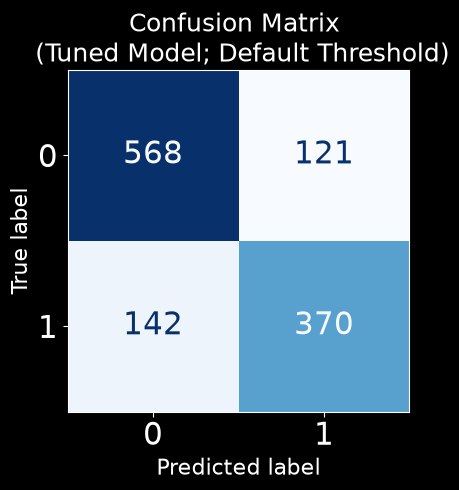

In [18]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = logistic_regression_tuned.predict(X_val_tfidf)

# Confusion Matrix for tuned model at default threshold (0.5)
cm_default = confusion_matrix(y_val, y_pred)
cm_default_df = pd.DataFrame(
    cm_default,
    index=["Actual: Not Disaster", "Actual: Disaster"],
    columns=["Predicted: Not Disaster", "Predicted: Disaster"]
)
print(cm_default_df)
print()

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred,
    colorbar=False,
    cmap="Blues",
    ax=ax
)

# Numbers inside matrix
for text in disp.text_.flatten():
    text.set_fontsize(22)

# Axis tick labels (0, 1)
ax.tick_params(labelsize=22)

# Axis titles (Predicted label / True label)
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)

plt.title("Confusion Matrix \n (Tuned Model; Default Threshold)", fontsize=18)
plt.tight_layout()
plt.savefig("confusion_matrix_tuned_model_default_threshold.jpeg", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation: Baseline vs. Tuned Model

The hyperparameter tuning, optimized specifically for recall on the disaster
class, improves recall from 0.67 (baseline) to 0.72 (tuned) on the validation
set. This confirms that targeted tuning successfully shifts the model toward
catching more disaster tweets, consistent with the project's emphasis on
minimizing missed disasters.

The gain comes at a cost: precision for the disaster class drops from 0.84 to
0.75. The weighted F1 score for the disaster class stays constant at 0.74, as
the recall gain and precision loss offset each other. This trade-off is
expected and intentional, since the tuning objective was recall rather than
overall F1.

## Stability of Predictions Assessed via 10-Fold Cross-Validation

In [19]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, recall_score

recall_class1_scorer = make_scorer(recall_score, pos_label=1)

# 10-fold cross-validation with the selected hyperparameters, to assess stability
recall_scores_list = cross_val_score(
    LogisticRegression(max_iter=1000, C=best_params["C"]),
    X_train_tfidf,
    y_train,
    cv=10,
    scoring=recall_class1_scorer
)

print(f"Recall Scores per fold: {recall_scores_list}")
print("Recall Mean: {:.3f}".format(recall_scores_list.mean()))
print("Recall Std: {:.3f}".format(recall_scores_list.std()))

Recall Scores per fold: [0.71219512 0.65686275 0.68137255 0.65196078 0.69607843 0.68780488
 0.68780488 0.69268293 0.65365854 0.68780488]
Recall Mean: 0.681
Recall Std: 0.019


**INTERPRETATION**
- 10-fold cross-validation on the training data yields a mean recall score of 0.681 with a standard deviation of 0.019.
- The low standard deviation indicates:
  - (a) a consistent model performs across different subsets of the training data
  - (b) stable generalization behavior of the model

# Threshold Selection for Disaster Detection

## Rationale
- The evaluation above reports performance at the default classification probability threshold of 0.5, meaning all tweets with a predicted disaster probability above 0.5 are classified as disaster.
- The following section explores how adjusting this threshold affects the trade-off between precision and recall for the disaster class, motivated by the real-world asymmetry of error costs.
- A minimum recall of 0.85 for the disaster class is desired as the selection criterion, reflecting the assumption that missing at most 15% of actual disaster tweets is an acceptable upper bound in a real-world detection context.

## Recall & Precision vs. Classification Threshold

     threshold  precision    recall
482   0.251246   0.618440  0.851562
483   0.253212   0.619658  0.849609
484   0.254225   0.620542  0.849609



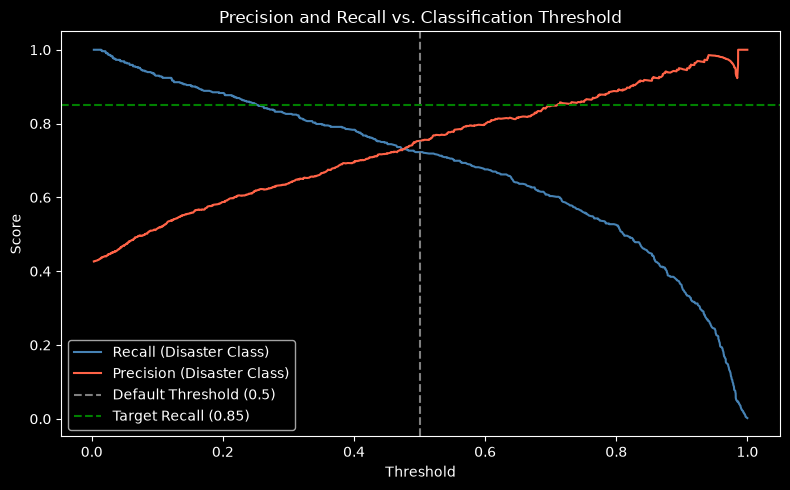

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, classification_report

# Get predicted probabilities for disaster class (label 1) on validation set
y_prob = logistic_regression_tuned.predict_proba(X_val_tfidf)[:, 1]

# Predictions at default threshold (0.5) on validation set
y_pred = logistic_regression_tuned.predict(X_val_tfidf)

# Compute precision and recall for all thresholds
precision, recall, pr_thresholds = precision_recall_curve(y_val, y_prob)

# Store precision, recall and thresholds as DataFrame for inspection
pr_df = pd.DataFrame({
    "threshold": pr_thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

print(pr_df[(pr_df["recall"] >= 0.848) & (pr_df["recall"] <= 0.853)])
print()

# Plot Recall and Precision against threshold
plt.figure(figsize=(8, 5))
plt.plot(pr_thresholds, recall[:-1], label="Recall (Disaster Class)", color="steelblue")
plt.plot(pr_thresholds, precision[:-1], label="Precision (Disaster Class)", color="tomato")
plt.axvline(x=0.5, color="gray", linestyle="--", label="Default Threshold (0.5)")
plt.axhline(y=0.85, color="green", linestyle="--", label="Target Recall (0.85)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs. Classification Threshold")
plt.legend()
plt.tight_layout()
plt.savefig("threshold_optimization.jpeg", dpi=150, bbox_inches="tight")
plt.show()

## Threshold selection

In [21]:
# Define minimum acceptable recall for the disaster class
target_recall = 0.85

# Filter all threshold candidates where recall meets the target
valid = pr_df[pr_df["recall"] >= target_recall]

# Sort valid candidates by precision descending and select the best row
best_row = valid.sort_values("precision", ascending=False).iloc[0]

# Extract the selected threshold value
best_threshold = best_row["threshold"]

# Apply selected threshold to generate optimized predictions
# .astype(int) converts boolean array (True/False) to integer array (1/0)
# consistent with y_pred and y_val
y_pred_optimized = (y_prob >= best_threshold).astype(int)

# Compare classification reports for default vs selected threshold
print("\nDefault threshold (0.50):")
print(classification_report(y_val, y_pred))

print(f"\nSelected threshold ({best_threshold:.3f}):")
print(classification_report(y_val, y_pred_optimized))

# Print key metrics at selected threshold
print(f"Selected threshold for disaster class recall >= 0.85: {best_threshold:.3f}")
print(f"Actual recall at selected threshold: {best_row['recall']:.3f}")
print(f"Precision at selected threshold: {best_row['precision']:.3f}")


Default threshold (0.50):
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       689
           1       0.75      0.72      0.74       512

    accuracy                           0.78      1201
   macro avg       0.78      0.77      0.77      1201
weighted avg       0.78      0.78      0.78      1201


Selected threshold (0.250):
              precision    recall  f1-score   support

           0       0.85      0.61      0.71       689
           1       0.62      0.85      0.72       512

    accuracy                           0.71      1201
   macro avg       0.73      0.73      0.71      1201
weighted avg       0.75      0.71      0.71      1201

Selected threshold for disaster class recall >= 0.85: 0.250
Actual recall at selected threshold: 0.854
Precision at selected threshold: 0.619


In [22]:
# Combine predicted probabilities and labels into a DataFrame for inspection
pred_df = pd.DataFrame({
    "y_prob": y_prob,
    "y_predicted_threshold_0_5": y_pred,
    f"y_pred_threshold_{best_threshold:.3f}".replace(".", "_"): y_pred_optimized,
    "y_true": y_val.values
})

pred_df.head(10)

,y_prob,y_predicted_threshold_0_5,y_pred_threshold_0_250,y_true
0,0.034906,0,0,0
1,0.036986,0,0,0
2,0.130937,0,0,0
3,0.008627,0,0,0
4,0.965452,1,1,1
5,0.058850,0,0,0
6,0.809520,1,1,1
7,0.197516,0,0,0
8,0.451078,0,1,0
9,0.016795,0,0,0


## Confusion Matrix (optimized threshold)

                      Predicted: Not Disaster  Predicted: Disaster
Actual: Not Disaster                      420                  269
Actual: Disaster                           75                  437



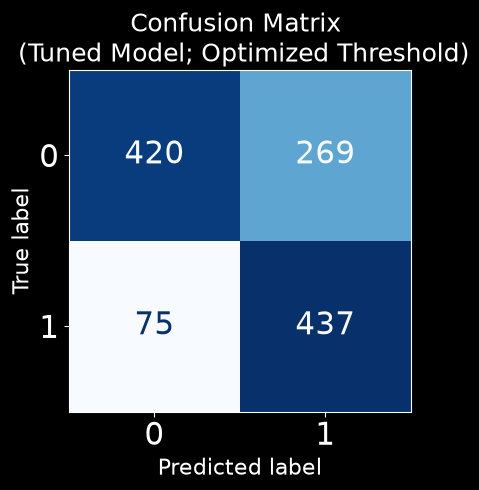

In [23]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix for optimized classification threshold
cm_optimized = confusion_matrix(y_val, y_pred_optimized)
cm_optimized_df = pd.DataFrame(
    cm_optimized,
    index=["Actual: Not Disaster", "Actual: Disaster"],
    columns=["Predicted: Not Disaster", "Predicted: Disaster"]
)
print(cm_optimized_df)
print()

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_optimized,
    colorbar=False,
    cmap="Blues",
    ax=ax
)

# Numbers inside matrix
for text in disp.text_.flatten():
    text.set_fontsize(22)

# Axis tick labels (0, 1)
ax.tick_params(labelsize=22)

# Axis titles (Predicted label / True label)
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)

plt.title("Confusion Matrix \n (Tuned Model; Optimized Threshold)", fontsize=18)
plt.tight_layout()
plt.savefig("confusion_matrix_tuned_model_threshold_optimized.jpeg", dpi=150, bbox_inches="tight")
plt.show()

## Interpretation
- Among all classification thresholds ensuring a minimum recall of 0.85, the one maximizing precision for the disaster class was selected, yielding a threshold of 0.250.

- At the default threshold of 0.50, the model misses 142 out of 512 actual disaster tweets (false negatives), achieving a recall of 0.72 for the disaster class
- Lowering the threshold to 0.250 increases recall for the disaster class to 0.85, reducing missed disasters from 142 to 75
- This comes at a considerable cost: false alarms increase from 121 to 269, meaning precision for the disaster class drops from 0.75 to 0.62
- The weighted average F1 score decreases from 0.78 to 0.71, reflecting the precision loss
- In a real-world disaster detection context, this trade-off is justified: a missed disaster carries a fundamentally higher cost than a false alarm. The selected threshold of 0.250 is therefore preferable for deployment despite the lower overall F1 score

# Final Performance Evaluation on Test Set

In [24]:
# Apply final TF-IDF vectorizer (fitted on training data) to test set
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Generate predictions using tuned model and optimized threshold
y_prob_test = logistic_regression_tuned.predict_proba(X_test_tfidf)[:, 1]
y_pred_test_final = (y_prob_test >= best_threshold).astype(int)

# Classification report
print(classification_report(y_test, y_pred_test_final))

              precision    recall  f1-score   support

           0       0.84      0.62      0.72       861
           1       0.62      0.84      0.72       640

    accuracy                           0.72      1501
   macro avg       0.73      0.73      0.72      1501
weighted avg       0.75      0.72      0.72      1501



                      Predicted: Not Disaster  Predicted: Disaster
Actual: Not Disaster                      538                  323
Actual: Disaster                          102                  538



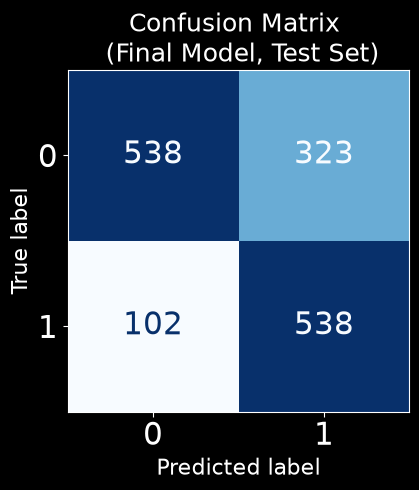

In [25]:
# Confusion matrix
cm_test = confusion_matrix(y_test, y_pred_test_final)
cm_test_df = pd.DataFrame(
    cm_test,
    index=["Actual: Not Disaster", "Actual: Disaster"],
    columns=["Predicted: Not Disaster", "Predicted: Disaster"]
)
print(cm_test_df)
print()

fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test_final,
    colorbar=False,
    cmap="Blues",
    ax=ax
)

for text in disp.text_.flatten():
    text.set_fontsize(22)

ax.tick_params(labelsize=22)
ax.set_xlabel(ax.get_xlabel(), fontsize=16)
ax.set_ylabel(ax.get_ylabel(), fontsize=16)

plt.title("Confusion Matrix \n (Final Model, Test Set)", fontsize=18)
plt.tight_layout()
plt.savefig("confusion_matrix_test_final.jpeg", dpi=150, bbox_inches="tight")
plt.show()

# Model Interpretation and Error Analysis
## Feature Importance
### Overview in Dataframes

In [26]:
import pandas as pd

# Extract feature names and model coefficients
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = logistic_regression_tuned.coef_[0]

# Create DataFrame with all features and corresponding coefficients
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Disaster class: highest positive coefficients
top_disaster = feature_importance.sort_values("coefficient", ascending=False).copy()
top_disaster["class"] = "disaster"

# Non-disaster class: highest negative coefficients
top_non_disaster = feature_importance.sort_values("coefficient", ascending=True).copy()
top_non_disaster["class"] = "non_disaster"

# Display top features for each class
print(top_disaster.head(20))
print()
print(top_non_disaster.head(20))

              feature  coefficient     class
3006        hiroshima     6.965707  disaster
9770         wildfire     5.693289  disaster
3394            japan     5.502929  disaster
1927       earthquake     5.347932  disaster
2360             fire     5.347870  disaster
2428            flood     5.211735  disaster
930        california     5.145657  disaster
756           bombing     4.984566  disaster
8048          rioting     4.944455  disaster
4878             near     4.660038  disaster
1774         distance     4.513592  disaster
2834        hailstorm     4.340001  disaster
9226            train     4.141634  disaster
8904         survivor     4.037638  disaster
9613              war     4.016427  disaster
2097        evacuated     3.983171  disaster
2101       evacuation     3.894315  disaster
3499           killed     3.893719  disaster
8854  suicide bombing     3.785195  disaster
1588           debris     3.779834  disaster

       feature  coefficient         class
3173        

### Barplot

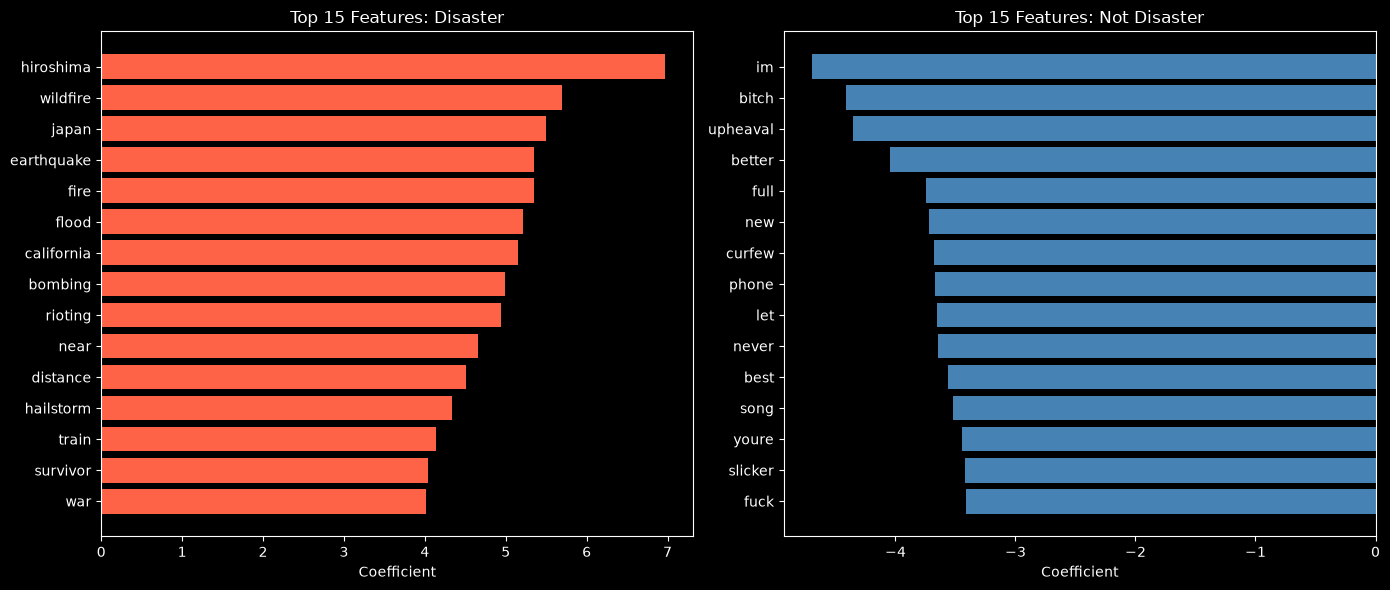

In [27]:
import matplotlib.pyplot as plt

# Select top 15 for each class
top15_disaster = top_disaster.head(15)
top15_non_disaster = top_non_disaster.head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Disaster class
axes[0].barh(top15_disaster["feature"], top15_disaster["coefficient"], color="tomato")
axes[0].set_title("Top 15 Features: Disaster")
axes[0].set_xlabel("Coefficient")
axes[0].invert_yaxis()

# Non-disaster class
axes[1].barh(top15_non_disaster["feature"], top15_non_disaster["coefficient"], color="steelblue")
axes[1].set_title("Top 15 Features: Not Disaster")
axes[1].set_xlabel("Coefficient")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("top15_features.jpeg", dpi=150, bbox_inches="tight")
plt.show()

The feature importance analysis for the recall-tuned model (C=10, ngram_range=(1,2), max_features=10000) shows largely plausible, generalizable disaster terms among the top predictors: "wildfire", "earthquake", "fire", "flood", "bombing", "rioting" and "hailstorm" are unambiguous, domain-specific vocabulary that should transfer well to unseen data.

However, several features illustrate the limits of this generalizability. "california" and "japan" are geographic names rather than substantive disaster terms, likely reflecting the prevalence of specific regional coverage (e.g. wildfires, earthquakes) in the training corpus rather than a transferable signal; applied to data from a different region or time period, they could mislead rather than help. "train" is a neutral, everyday word with no inherent disaster connotation, possibly correlating with the training data by chance (e.g. through phrases like "train crash") rather than carrying genuine predictive meaning on their own.

"hiroshima" stands out as the single strongest predictor by a wide margin. Like "california" and "japan", it reflects a specific historical event prominently represented in the training data rather than a generalizable disaster signal, and is unlikely to transfer to future, unrelated disaster tweets.

On the non-disaster side, "slicker" is a notable case: it appears among the strongest non-disaster predictors despite originating from a disaster-adjacent idiom ("slicker than an oil spill"), illustrating how figurative language can push a term toward the opposite class from what its literal meaning would suggest.

These cases point to a broader limitation: with a relatively small and topically concentrated training set, the model can pick up dataset-specific artifacts and figurative associations alongside genuine disaster vocabulary. More diverse training data, covering multiple regions, time periods and event types, or contextualised embeddings such as Sentence-BERT that capture meaning beyond individual keywords, would help the model generalize the disaster concept itself rather than this specific dataset's geography, vocabulary and idiomatic usage.

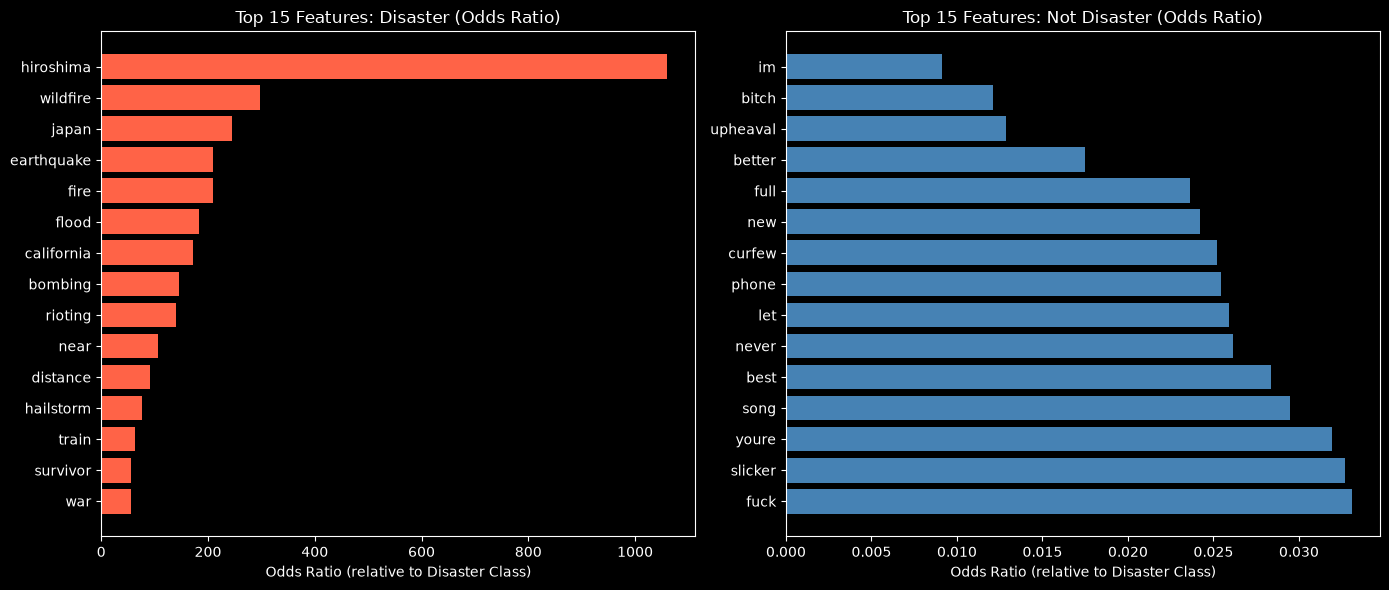

In [28]:
import numpy as np

# Calculate odds ratios from logistic regression coefficients
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = logistic_regression_tuned.coef_[0]
odds_ratios = np.exp(coefficients)

# Create DataFrame
feature_importance_or = pd.DataFrame({
    "feature": feature_names,
    "odds_ratio": odds_ratios
})

# Top 15 for and against disaster class
top_disaster_or = feature_importance_or.sort_values("odds_ratio", ascending=False).head(15)
top_non_disaster_or = feature_importance_or.sort_values("odds_ratio", ascending=True).head(15)

# Combine for plotting
top_disaster_or["class"] = "disaster"
top_non_disaster_or["class"] = "non_disaster"

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_disaster_or["feature"], top_disaster_or["odds_ratio"], color="tomato")
axes[0].set_title("Top 15 Features: Disaster (Odds Ratio)")
axes[0].set_xlabel("Odds Ratio (relative to Disaster Class)")
axes[0].invert_yaxis()

axes[1].barh(top_non_disaster_or["feature"], top_non_disaster_or["odds_ratio"], color="steelblue")
axes[1].set_title("Top 15 Features: Not Disaster (Odds Ratio)")
axes[1].set_xlabel("Odds Ratio (relative to Disaster Class)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("odds_ratios.jpeg", dpi=150, bbox_inches="tight")
plt.show()

## Error analysis

- False Negatives refer to actual disaster tweets that were incorrectly classified as non-disaster.
- The disaster class (label 1) is treated as the positive class throughout this analysis, as it represents the event of interest that the model is designed to detect.

In [29]:
# Add original text to error DataFrame using index alignment
error_df = pd.DataFrame({
    "text_original": df.loc[X_test.index, "text"].values,
    "text_clean": X_test.values,
    "y_true": y_test.values,
    "y_pred": y_pred_test_final
})

# False Negatives
false_negatives = error_df[(error_df["y_true"] == 1) & (error_df["y_pred"] == 0)]

# False Positives
false_positives = error_df[(error_df["y_true"] == 0) & (error_df["y_pred"] == 1)]

print("False Negatives:\n")
print(false_negatives.head(10))
print("\nFalse Positives:\n")
print(false_positives.head(10))

False Negatives:

                                                                                                                                    text_original  \
5              @SnowyWolf5 @TheGreenParty Besides would you rather shut down a whole nuclear reactor for maintenance or a wind turbine at a time?   
6    All you have to do is look up sports riots on google and you'll see more than couches being burned.. You fr gotta go https://t.co/P1AmgINsYs   
10                                        One Direction Is my pick for http://t.co/q2eBlOKeVE Fan Army #Directioners http://t.co/eNCmhz6y34 x1392   
14    @OllyMursAus I do feel sorry for him! He is not a piece of meat! He is a nice guy... People don't need to rush him and screams in his face!   
63          Bigamist and his 'first' wife are charged in the deaths of his 'second' pregnant wife her child 8 her mothe... http://t.co/rTEuGB5Tnv   
85         New Giant Flames (GIANT FULL BLACK PANTOFEL) info/order sms:087809233445 pin:

### Interpretation

**Data Quality: Labeling Errors**

A manual inspection of misclassified tweets reveals that a non-negligible share appear mislabeled in the dataset. Examples labeled as disaster despite no disaster content: "I can't drown my demons they know how to swim" (a song lyric), "'It looks like a mudslide' poor thing! #greatbritishbakeoff" (a baking show comment), "We need these plants in the pacific during the cyclone seasons" (a wind energy comment). In these cases the model prediction is arguably more accurate than the ground truth label, highlighting the inherent noise in crowdsourced annotation.

**False Negatives: real disaster content missed by the model**

The dominant pattern is real crisis content framed in neutral or informal language that lacks the high-weight disaster keywords the model relies on. Without terms like "earthquake", "wildfire" or "flood", TF-IDF has little signal:

* "Newlyweds feed thousands of Syrian refugees instead of hosting a banquet": humanitarian crisis in neutral everyday language
* "A subcontractor working for CGG has been kidnapped in Cairo and is held by Islamic State": a real crisis in neutral news language
* Heavily fragmented or dialectal tweets further reduce overlap with the learned disaster vocabulary

**False Positives: non-disaster content flagged as disaster**

High-weight disaster terms appearing in non-disaster contexts drive most false positives: "slicker than an oil spill" (idiom), "Mercury Cyclone GT" (car model), "two hours of Sandstorm remixes" (music track), "if firefighters acted like cops shooting a flamethrower" (hypothetical).

These failure modes would be partially addressed by contextualised embeddings such as Sentence-BERT, which represent words differently depending on their surrounding context.

### Pragmatic Decision

Labels are treated as correct for the remainder of this analysis. This
is a simplification that does not fully reflect the data quality issues
observed above, but is necessary to keep the scope manageable.

# Conclusion

This project developed a text classification pipeline to distinguish between
tweets reporting real disasters and those that do not. The pipeline consists
of a text preprocessing step, TF-IDF vectorization and Logistic Regression
as the classifier, with hyperparameter tuning explicitly optimized for recall
on the disaster class via 10-fold cross-validation, motivated by the higher
real-world cost of missed disasters compared to false alarms.

On the held-out test set, the final model achieves a recall of 0.84 for the
disaster class at a precision of 0.62, with a weighted F1 score of 0.72. This
confirms that the model reliably catches the large majority of real disaster
tweets, at the cost of a substantial number of false alarms.

The tuning process selected weak regularization (C=10), as this configuration
maximized recall for the disaster class — the sole optimization target.
On top of this recall-tuned model, the classification threshold was further lowered (from 0.50 to 0.25)
to reach a target recall of 0.85 on the validation set. These two
recall-oriented adjustments compound each other: the tuned model already
leans toward the disaster class, so the additional threshold shift causes a
steeper precision drop than threshold adjustment alone would produce. The
takeaway: combining a recall-optimized model with a recall-optimized
threshold amplifies the precision trade-off rather than simply adding to it.

The error analysis reveals that the model relies on high-frequency
disaster-related terms identified in the feature importance analysis. While
these features are largely semantically plausible, TF-IDF optimises purely
on statistical co-occurrence and can assign high weight to terms that reflect
geographic or temporal specificities of the training data rather than
generalizable disaster signals. The model systematically fails on non-literal
language and neutral framing of real events, and a non-negligible share of
misclassifications can be attributed to labeling noise in the original
dataset.

As a next step, contextualised embedding methods such as Sentence-BERT could
partially address the context-blindness of TF-IDF. However, for short,
keyword-driven texts like tweets, the expected performance gain without
fine-tuning is modest, and the TF-IDF baseline proves to be an interpretable and reasonable starting
point for this task, though its lack of contextual understanding sets a clear
ceiling on achievable precision.